In [1]:
from pathlib import Path

pth_path = Path("C:/SmartMeal/models/resnet18_food101.pth")

if pth_path.exists():
    size_mb = pth_path.stat().st_size / (1024**2)
    print(f"✅ Fichier trouvé !")
    print(f"📂 Chemin : {pth_path}")
    print(f"💾 Taille : {size_mb:.1f} MB")
else:
    print(f"❌ Fichier NON trouvé à : {pth_path}")
    print(f"\n📂 Contenu actuel de models/ :")
    models_dir = Path("C:/SmartMeal/models")
    for f in models_dir.iterdir():
        size = f.stat().st_size / (1024**2)
        print(f"   {f.name} — {size:.1f} MB")

❌ Fichier NON trouvé à : C:\SmartMeal\models\resnet18_food101.pth

📂 Contenu actuel de models/ :
   resnet18_food10.pth — 42.7 MB
   rl_results.json — 0.0 MB


In [2]:
import shutil
from pathlib import Path

# Chercher automatiquement dans Downloads
possible_locations = [
    Path("C:/Users/pc/Downloads/resnet18_food101.pth"),
    Path("C:/Users/pc/Desktop/resnet18_food101.pth"),
    Path("C:/Users/pc/Documents/resnet18_food101.pth"),
]

found = None
for loc in possible_locations:
    if loc.exists():
        found = loc
        print(f"✅ Trouvé : {loc}")
        break

if found:
    dst = Path("C:/SmartMeal/models/resnet18_food101.pth")
    shutil.copy(str(found), str(dst))
    size = dst.stat().st_size / (1024**2)
    print(f"✅ Copié vers models/")
    print(f"💾 Taille : {size:.1f} MB")
else:
    print("❌ Pas trouvé automatiquement")
    print("\n🔍 Cherche manuellement :")
    print("   1. Ouvre l'Explorateur Windows")
    print("   2. Va dans C:/Users/pc/Downloads/")
    print("   3. Cherche 'resnet18_food101.pth'")
    print("   4. Copie-le dans C:/SmartMeal/models/")

✅ Trouvé : C:\Users\pc\Downloads\resnet18_food101.pth
✅ Copié vers models/
💾 Taille : 43.9 MB


In [3]:
# Lire le fichier app.py et corriger le warning
with open("C:/SmartMeal/src/app.py", "r", encoding="utf-8") as f:
    content = f.read()

# Remplacer use_column_width par use_container_width
content = content.replace(
    "use_column_width=True",
    "use_container_width=True"
)

with open("C:/SmartMeal/src/app.py", "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Warning corrigé !")


✅ Warning corrigé !


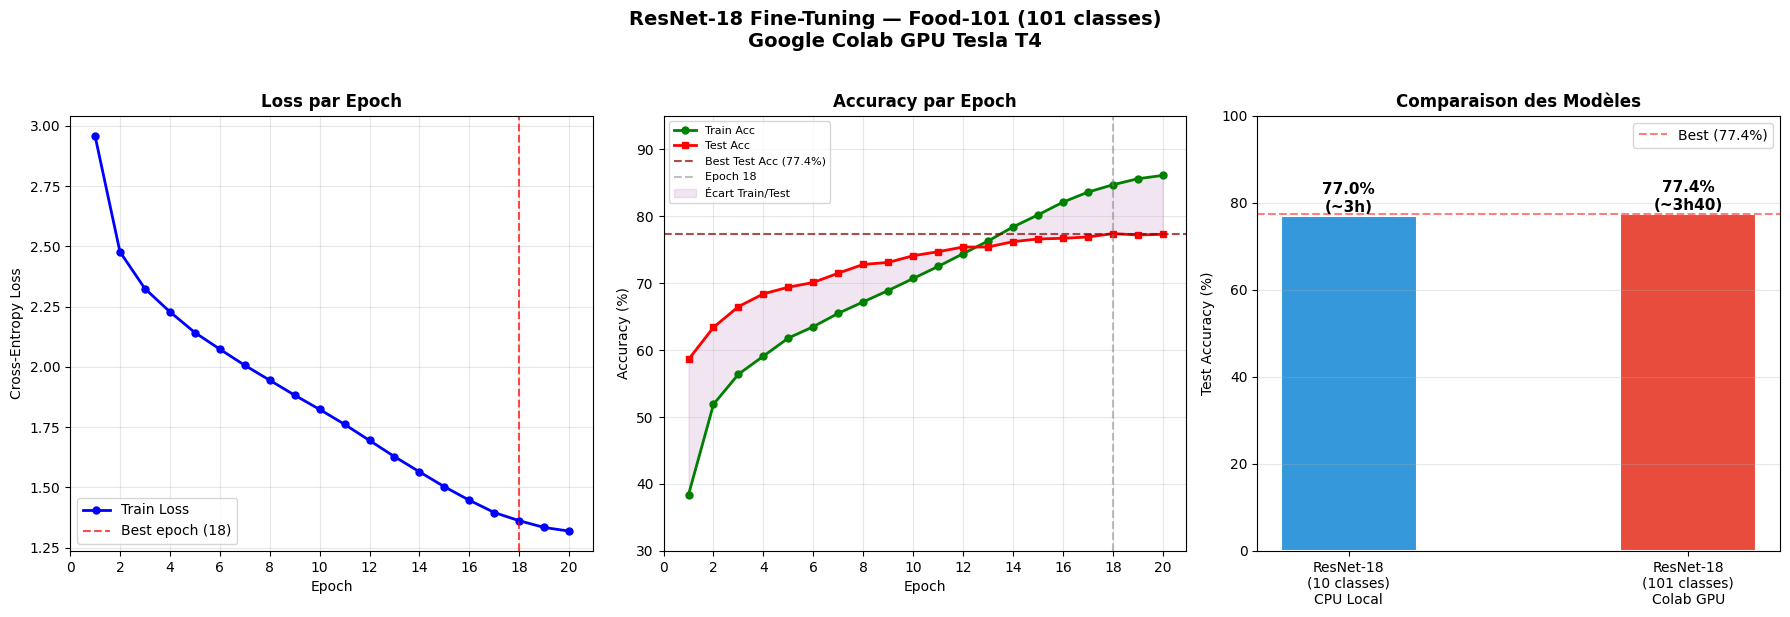

✅ Courbe ResNet-18 (101 classes) sauvegardée !
📂 C:/SmartMeal/reports/resnet18_food101_training.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ── Données réelles de ton entraînement Colab ─────────────
epochs     = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
train_acc  = [38.4, 51.9, 56.4, 59.1, 61.8, 63.5, 65.5, 67.2, 68.9, 70.7,
              72.5, 74.4, 76.3, 78.4, 80.2, 82.1, 83.6, 84.7, 85.6, 86.1]
test_acc   = [58.6, 63.4, 66.5, 68.4, 69.4, 70.1, 71.5, 72.8, 73.1, 74.1,
              74.7, 75.4, 75.4, 76.2, 76.6, 76.7, 76.9, 77.4, 77.2, 77.3]
train_loss = [2.960, 2.478, 2.325, 2.229, 2.143, 2.074, 2.007, 1.945, 1.883, 1.824,
              1.762, 1.695, 1.628, 1.565, 1.503, 1.447, 1.396, 1.362, 1.334, 1.319]

best_epoch = 18
best_acc   = 77.4

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("ResNet-18 Fine-Tuning — Food-101 (101 classes)\nGoogle Colab GPU Tesla T4",
             fontsize=14, fontweight="bold", y=1.02)

# ── Plot 1 : Loss ─────────────────────────────────────────
axes[0].plot(epochs, train_loss, "b-o", linewidth=2,
             markersize=5, label="Train Loss")
axes[0].axvline(x=best_epoch, color="red", linestyle="--",
                alpha=0.7, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Loss par Epoch", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 21, 2))

# ── Plot 2 : Accuracy ─────────────────────────────────────
axes[1].plot(epochs, train_acc, "g-o", linewidth=2,
             markersize=5, label="Train Acc")
axes[1].plot(epochs, test_acc,  "r-s", linewidth=2,
             markersize=5, label="Test Acc")
axes[1].axhline(y=best_acc, color="darkred", linestyle="--",
                alpha=0.7, label=f"Best Test Acc ({best_acc}%)")
axes[1].axvline(x=best_epoch, color="gray", linestyle="--",
                alpha=0.5, label=f"Epoch {best_epoch}")
axes[1].fill_between(epochs, train_acc, test_acc,
                     alpha=0.1, color="purple", label="Écart Train/Test")
axes[1].set_title("Accuracy par Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 21, 2))
axes[1].set_ylim(30, 95)

# ── Plot 3 : Comparaison 10 vs 101 classes ────────────────
models      = ["ResNet-18\n(10 classes)\nCPU Local", "ResNet-18\n(101 classes)\nColab GPU"]
test_accs   = [77.0, 77.4]
train_times = ["~3h", "~3h40"]
colors      = ["#3498db", "#e74c3c"]

bars = axes[2].bar(models, test_accs, color=colors,
                   width=0.4, edgecolor="white", linewidth=1.5)
axes[2].set_ylim(0, 100)
axes[2].set_title("Comparaison des Modèles", fontweight="bold")
axes[2].set_ylabel("Test Accuracy (%)")
axes[2].axhline(y=77.4, color="red", linestyle="--",
                alpha=0.5, label="Best (77.4%)")

for bar, acc, time in zip(bars, test_accs, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{acc}%\n({time})", ha="center", fontsize=11,
                fontweight="bold")

axes[2].grid(True, alpha=0.3, axis="y")
axes[2].legend()

plt.tight_layout()
plt.savefig("C:/SmartMeal/reports/resnet18_food101_training.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Courbe ResNet-18 (101 classes) sauvegardée !")
print("📂 C:/SmartMeal/reports/resnet18_food101_training.png")

In [1]:
# ========================================
# ERROR ANALYSIS - Confusion Matrix & False Positives/Negatives
# ========================================

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred, class_names, top_n=20):
    """Visualiser les confusions entre les top N classes"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Si trop de classes, afficher les 20 premières
    if len(class_names) > top_n:
        indices = sorted(set(list(y_true[:top_n]) + list(y_pred[:top_n])))
        cm = cm[np.ix_(indices, indices)]
        top_classes = [class_names[i] for i in indices]
    else:
        top_classes = class_names
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=top_classes, yticklabels=top_classes, cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - ResNet-18 Food-101', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# 2. CLASSIFICATION REPORT
def print_detailed_metrics(y_true, y_pred, class_names):
    """Rapport détaillé par classe"""
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)
    
    # Sauvegarder
    with open('classification_report.txt', 'w') as f:
        f.write(report)

# 3. VISUALISER LES ERREURS
def visualize_misclassifications(images, y_true, y_pred, probs, class_names, num_samples=12):
    """Afficher les FP et FN"""
    mistakes = y_true != y_pred
    mistake_indices = np.where(mistakes)[0]
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, ax_idx in enumerate(mistake_indices[:12]):
        img = images[ax_idx]
        true_label = class_names[y_true[ax_idx]]
        pred_label = class_names[y_pred[ax_idx]]
        confidence = probs[ax_idx, y_pred[ax_idx]]
        
        # Normaliser l'image si nécessaire
        if img.shape[0] == 3:  # Si en format (C, H, W)
            img = img.transpose(1, 2, 0)
        if img.max() <= 1.0:
            img = img * 255
        
        axes[idx].imshow(img.astype('uint8'))
        axes[idx].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2%})', 
                           color='red', fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('misclassifications.png', dpi=300, bbox_inches='tight')
    plt.show()

# 4. ANALYSE PAR CLASSE
def worst_performing_classes(y_true, y_pred, class_names, top_k=10):
    """Les classes les plus mal reconnues"""
    class_errors = {}
    
    for true_idx in range(len(class_names)):
        mask = y_true == true_idx
        if mask.sum() == 0:
            continue
        accuracy = (y_pred[mask] == true_idx).mean()
        class_errors[class_names[true_idx]] = accuracy
    
    sorted_errors = sorted(class_errors.items(), key=lambda x: x[1])
    
    print(f"\n{'='*60}")
    print(f"Top {top_k} Classes with Worst Recognition")
    print(f"{'='*60}")
    for cls, acc in sorted_errors[:top_k]:
        print(f"{cls:30s} : {acc:.2%}")
    
    # Visualiser
    classes_worst, accs_worst = zip(*sorted_errors[:top_k])
    plt.figure(figsize=(12, 6))
    plt.barh(classes_worst, accs_worst, color='coral')
    plt.xlabel('Accuracy', fontsize=12)
    plt.title('Bottom 10 Classes - Lowest Accuracy', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('worst_classes.png', dpi=300, bbox_inches='tight')
    plt.show()

# UTILISATION (à faire sur l'ensemble test)
# En fin d'entraînement du modèle:
model.eval()
all_preds = []
all_labels = []
all_images = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_images.extend(images.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Générer les analyses
plot_confusion_matrix(all_labels, all_preds, class_names)
print_detailed_metrics(all_labels, all_preds, class_names)
visualize_misclassifications(all_images, all_labels, all_preds, all_probs, class_names)
worst_performing_classes(all_labels, all_preds, class_names)

NameError: name 'model' is not defined